In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad
import trimesh

In [66]:
# TPC boundaries (cm)
tpcMinX = -200
tpcMaxX = 200
tpcMinY = -200
tpcMaxY = 200
tpcMinZ = 0
tpcMaxZ = 500
tpcProjZFront = tpcMinZ

'''
# Fiducial volume boundaries (cm)
tpcMinX = -183.5
tpcMaxX = 183.5
tpcMinY = -185
tpcMaxY = 185
tpcMinZ = 40 # start of the fiducial volume, where 0 is the front face of the tpc
tpcMaxZ = 460
tpcProjZFront = 0
'''

# Beam center (cm)
beamCenterX = -74
beamCenterY = 0
beamCenterZ = 11000 # front face of the tpc, where 0 is the beam target

In [67]:
# Plot settings
colorTot = 'C3'; colorP = 'C0'; colorNP = 'C1'
ylimit = (0,)
xlimit=(0,)
erAlpha = 0.3

nbins = np.arange(0, 4.1, .2)
nbinsTPC = np.arange(0, 1.81, .05)

In [68]:
# exact volume normalization
tpcBox = trimesh.creation.box(extents=[(tpcMaxX-tpcMinX)/100, (tpcMaxY-tpcMinY)/100, (tpcMaxZ-tpcMinZ)/100])
tpcBox.apply_translation([beamCenterX/100, beamCenterY/100, (tpcMaxZ-tpcMinZ)/200])
norm_vols = np.array([])
for i in range(len(nbinsTPC)-1):
    radius = ((beamCenterZ+tpcMaxZ)/100) * np.tan(nbinsTPC[i+1] * np.pi / 180)
    cone = trimesh.creation.cone(radius=radius, height=((beamCenterZ+tpcMaxZ)/100))
    vol = cone.volume - cone.difference(tpcBox).volume
    if i > 0:
        vol -= np.sum(norm_vols[0:i])
    if vol < 1e-5:
        vol = 0
    norm_vols = np.append(norm_vols, vol)
norm_vols

array([1.50451742e-01, 4.51355948e-01, 7.52263019e-01, 1.05317542e+00,
       1.35409380e+00, 1.65501781e+00, 1.95595575e+00, 2.25690737e+00,
       2.55786691e+00, 2.85884371e+00, 3.15984034e+00, 3.46085094e+00,
       3.73681095e+00, 3.68521307e+00, 3.70380285e+00, 3.78682787e+00,
       3.90077898e+00, 4.01973656e+00, 4.14604481e+00, 4.28335815e+00,
       4.03894480e+00, 3.28052182e+00, 2.83918841e+00, 2.52556850e+00,
       2.32223253e+00, 2.27269323e+00, 2.24099869e+00, 2.16127206e+00,
       1.71109926e+00, 1.26387835e+00, 9.51339288e-01, 7.03302182e-01,
       4.64837284e-01, 2.34516768e-01, 5.87408036e-02, 1.65377018e-03])

In [69]:
# Front face normalization v1
norm_areas = np.array([])
r1 = min(abs(tpcMinX - beamCenterX)/100, abs(tpcMaxX - beamCenterX)/100)  # m
r2 = min(abs(tpcMinY - beamCenterY)/100, abs(tpcMaxY - beamCenterY)/100)  # m
r4 = max(abs(tpcMinX - beamCenterX)/100, abs(tpcMaxX - beamCenterX)/100)  # m
for i in range(len(nbinsTPC)-1):
    radius = ((beamCenterZ+tpcProjZFront)/100) * np.tan(nbinsTPC[i+1] * np.pi / 180)
    area = np.pi * radius**2
    if i > 0:
        if radius > r1:
            area -= quad(lambda x: 2*np.sqrt(radius**2 - x**2), r1, radius)[0]
        if radius > r2:
            area -= quad(lambda y: 4*np.sqrt(radius**2 - y**2), r2, radius)[0]
        if radius > np.sqrt(r1**2 + r2**2):
            area += quad(lambda x1: 2*(np.sqrt(radius**2 - x1**2) - 2), r1, np.sqrt(radius**2 - r2**2))[0]
        if radius > r4:
            area -= quad(lambda z: 2*np.sqrt(radius**2 - z**2), r4, radius)[0]
        if radius > np.sqrt(r4**2 + r2**2):
            area += quad(lambda x2: 2*(np.sqrt(radius**2 - x2**2) - r2), r4, np.sqrt(radius**2 - r2**2))[0]
        area -= np.sum(norm_areas[0:i])
    if area < 1e-5:
        area = 0
    norm_areas = np.append(norm_areas, area)
norm_areas

array([0.02894878, 0.0868465 , 0.14474476, 0.2026439 , 0.26054428,
       0.31844624, 0.37635014, 0.43425633, 0.49216517, 0.55007701,
       0.6079922 , 0.6659111 , 0.72383405, 0.72907177, 0.722891  ,
       0.73757331, 0.75765482, 0.78041978, 0.80478147, 0.83018984,
       0.84542193, 0.68982269, 0.58960651, 0.52092456, 0.46740585,
       0.44967491, 0.44208392, 0.4359547 , 0.40152889, 0.28877848,
       0.22051625, 0.16601696, 0.11804667, 0.07404394, 0.03274081,
       0.00209047])

In [70]:
# front face normalization v2
tpcBox = trimesh.creation.box(extents=[(tpcMaxX-tpcMinX)/100, (tpcMaxY-tpcMinY)/100, (tpcMaxZ-tpcMinZ)/100])
tpcBox.apply_translation([beamCenterX/100, beamCenterY/100, 0])
norm_area_front = np.array([])
for i in range(len(nbinsTPC)-1):
    radius = ((beamCenterZ+tpcProjZFront)/100) * np.tan(nbinsTPC[i+1] * np.pi / 180)
    cylinder = trimesh.creation.cylinder(radius=radius, height=1)
    vol_front = cylinder.volume - cylinder.difference(tpcBox).volume
    if i > 0:
        vol_front -= np.sum(norm_area_front[0:i])
    if vol_front < 1e-5:
        vol_front = 0
    norm_area_front = np.append(norm_area_front, vol_front)
norm_area_front

array([0.02876312, 0.08628955, 0.14381649, 0.20134432, 0.25887337,
       0.31640399, 0.37393655, 0.43147138, 0.48900885, 0.54654929,
       0.60409306, 0.66164051, 0.719192  , 0.72833979, 0.71995251,
       0.73407636, 0.75424046, 0.77697219, 0.80005982, 0.82588788,
       0.84704591, 0.69890087, 0.59162189, 0.52505069, 0.46871435,
       0.44799165, 0.4419294 , 0.43587962, 0.40982002, 0.29370107,
       0.22484916, 0.17040385, 0.12480991, 0.07920691, 0.03552915,
       0.00363448])

In [71]:
# front face normalization v3
tpcBox = trimesh.creation.box(extents=[(tpcMaxX-tpcMinX)/100, (tpcMaxY-tpcMinY)/100, (tpcMaxZ-tpcMinZ)/100])
tpcBox.apply_translation([beamCenterX/100, beamCenterY/100, 0])
norm_area_front3 = np.array([])
for i in range(len(nbinsTPC)-1):
    rmin = ((beamCenterZ+tpcProjZFront)/100) * np.tan(nbinsTPC[i] * np.pi / 180)
    radius = ((beamCenterZ+tpcProjZFront)/100) * np.tan(nbinsTPC[i+1] * np.pi / 180)
    annulus = trimesh.creation.annulus(r_min=rmin, r_max=radius, height=1)
    vol_front3 = annulus.volume - annulus.difference(tpcBox).volume
    if vol_front3 < 1e-5:
        vol_front3 = 0
    norm_area_front3 = np.append(norm_area_front3, vol_front3)
norm_area_front3

array([0.02876312, 0.08628955, 0.14381649, 0.20134432, 0.25887337,
       0.31640399, 0.37393655, 0.43147138, 0.48900885, 0.54654929,
       0.60409306, 0.66164051, 0.719192  , 0.72833979, 0.71995251,
       0.73407636, 0.75424046, 0.77697219, 0.80005982, 0.82588788,
       0.84704591, 0.69890087, 0.59162189, 0.52505069, 0.46871435,
       0.44799165, 0.4419294 , 0.43587962, 0.40982002, 0.29370107,
       0.22484916, 0.17040385, 0.12480991, 0.07920691, 0.03552915,
       0.00363448])

In [72]:
# back face normalization
tpcBox = trimesh.creation.box(extents=[(tpcMaxX-tpcMinX)/100, (tpcMaxY-tpcMinY)/100, (tpcMaxZ-tpcMinZ)/100])
tpcBox.apply_translation([beamCenterX/100, beamCenterY/100, 0])
norm_area_back = np.array([])
for i in range(len(nbinsTPC)-1):
    radius = ((beamCenterZ+tpcMaxZ)/100) * np.tan(nbinsTPC[i+1] * np.pi / 180)
    cylinder_back = trimesh.creation.cylinder(radius=radius, height=1)
    vol_back = cylinder_back.volume - cylinder_back.difference(tpcBox).volume
    if i > 0:
        vol_back -= np.sum(norm_area_back[0:i])
    if vol_back < 1e-5:
        vol_back = 0
    norm_area_back = np.append(norm_area_back, vol_back)
norm_area_back

array([0.03143738, 0.09431233, 0.15718786, 0.22006435, 0.28294217,
       0.34582172, 0.40870338, 0.47158752, 0.53447454, 0.59736482,
       0.66025874, 0.72315668, 0.76842103, 0.75059938, 0.76209426,
       0.78153246, 0.80632937, 0.83129502, 0.85901093, 0.88677965,
       0.74416296, 0.62079809, 0.54751475, 0.4872299 , 0.4676065 ,
       0.46099233, 0.45437804, 0.3991206 , 0.28512589, 0.21323614,
       0.15975573, 0.10992538, 0.06022267, 0.01655734, 0.        ,
       0.        ])

In [73]:
# back face normalization
tpcBox = trimesh.creation.box(extents=[(tpcMaxX-tpcMinX)/100, (tpcMaxY-tpcMinY)/100, (tpcMaxZ-tpcMinZ)/100])
tpcBox.apply_translation([beamCenterX/100, beamCenterY/100, 0])
norm_areas_back = np.array([])
for i in range(len(nbinsTPC)-1):
    rmin_back = ((beamCenterZ+tpcMaxZ)/100) * np.tan(nbinsTPC[i] * np.pi / 180)
    radius_back = ((beamCenterZ+tpcMaxZ)/100) * np.tan(nbinsTPC[i+1] * np.pi / 180)
    annulus_back = trimesh.creation.annulus(r_min=rmin_back, r_max=radius_back, height=1)
    vol_back = annulus_back.volume - annulus_back.difference(tpcBox).volume
    if vol_back < 1e-5:
        vol_back = 0
    norm_areas_back = np.append(norm_areas_back, vol_back)
norm_areas_back

array([0.03143738, 0.09431233, 0.15718786, 0.22006435, 0.28294217,
       0.34582172, 0.40870338, 0.47158752, 0.53447454, 0.59736482,
       0.66025874, 0.72315668, 0.76842103, 0.75059938, 0.76209426,
       0.78153246, 0.80632937, 0.83129502, 0.85901093, 0.88677965,
       0.74416296, 0.62079809, 0.54751475, 0.4872299 , 0.4676065 ,
       0.46099233, 0.45437804, 0.3991206 , 0.28512589, 0.21323614,
       0.15975573, 0.10992538, 0.06022267, 0.01655734, 0.        ,
       0.        ])

In [74]:
r1 = min(abs(tpcMinX - beamCenterX)/100, abs(tpcMaxX - beamCenterX)/100)  # m
r2 = min(abs(tpcMinY - beamCenterY)/100, abs(tpcMaxY - beamCenterY)/100)  # m
r3 = max(abs(tpcMinY - beamCenterY)/100, abs(tpcMaxY - beamCenterY)/100)  # m
r4 = max(abs(tpcMinX - beamCenterX)/100, abs(tpcMaxX - beamCenterX)/100)  # m

def subPerimeter(outerR, innerR, boundary, smallCorner, bigCorner):
    assert smallCorner <= bigCorner, "smallCorner must be less than or equal to bigCorner"
    assert smallCorner > boundary, "smallCorner must be bigger than distance to boundary"
    if outerR <= boundary or innerR > bigCorner:
        return 0
    if outerR <= smallCorner and innerR <= boundary:
        return 2*np.sqrt(outerR**2 - boundary**2)
    if outerR <= smallCorner and innerR > boundary and innerR <= smallCorner:
        return 2*(np.sqrt(outerR**2 - boundary**2) - np.sqrt(innerR**2 - boundary**2))
    if outerR > smallCorner and outerR <= bigCorner and innerR <= boundary:
        return np.sqrt(outerR**2 - boundary**2) + np.sqrt(smallCorner**2 - boundary**2)
    if outerR > bigCorner and innerR <= boundary:
        return np.sqrt(bigCorner**2 - boundary**2) + np.sqrt(smallCorner**2 - boundary**2)
    if outerR > smallCorner and outerR <= bigCorner and innerR > boundary and innerR <= smallCorner:
        return np.sqrt(outerR**2 - boundary**2) + np.sqrt(smallCorner**2 - boundary**2) - 2*np.sqrt(innerR**2 - boundary**2)
    if outerR > bigCorner and innerR > boundary and innerR <= smallCorner:
        return np.sqrt(bigCorner**2 - boundary**2) + np.sqrt(smallCorner**2 - boundary**2) - 2*np.sqrt(innerR**2 - boundary**2)
    if outerR > smallCorner and outerR <= bigCorner and innerR > smallCorner and innerR <= bigCorner:
        return np.sqrt(outerR**2 - boundary**2) - np.sqrt(innerR**2 - boundary**2)
    if outerR > bigCorner and innerR > smallCorner and innerR <= bigCorner:
        return np.sqrt(bigCorner**2 - boundary**2) - np.sqrt(innerR**2 - boundary**2)
    return -1        

def getPerimeterFront(outerAngle, innerAngle):
    r_max = ((beamCenterZ+tpcProjZFront)/100) * np.tan(outerAngle * np.pi / 180)
    r_min = ((beamCenterZ+tpcProjZFront)/100) * np.tan(innerAngle * np.pi / 180)
    perimeter = 0
    perimeter += subPerimeter(r_max, r_min, r1, np.sqrt(r1**2+r2**2), np.sqrt(r1**2+r3**2))
    perimeter += subPerimeter(r_max, r_min, r2, np.sqrt(r1**2+r2**2), np.sqrt(r4**2+r2**2))
    perimeter += subPerimeter(r_max, r_min, r3, np.sqrt(r1**2+r3**2), np.sqrt(r4**2+r3**2))
    perimeter += subPerimeter(r_max, r_min, r4, np.sqrt(r4**2+r2**2), np.sqrt(r4**2+r3**2))
    return perimeter

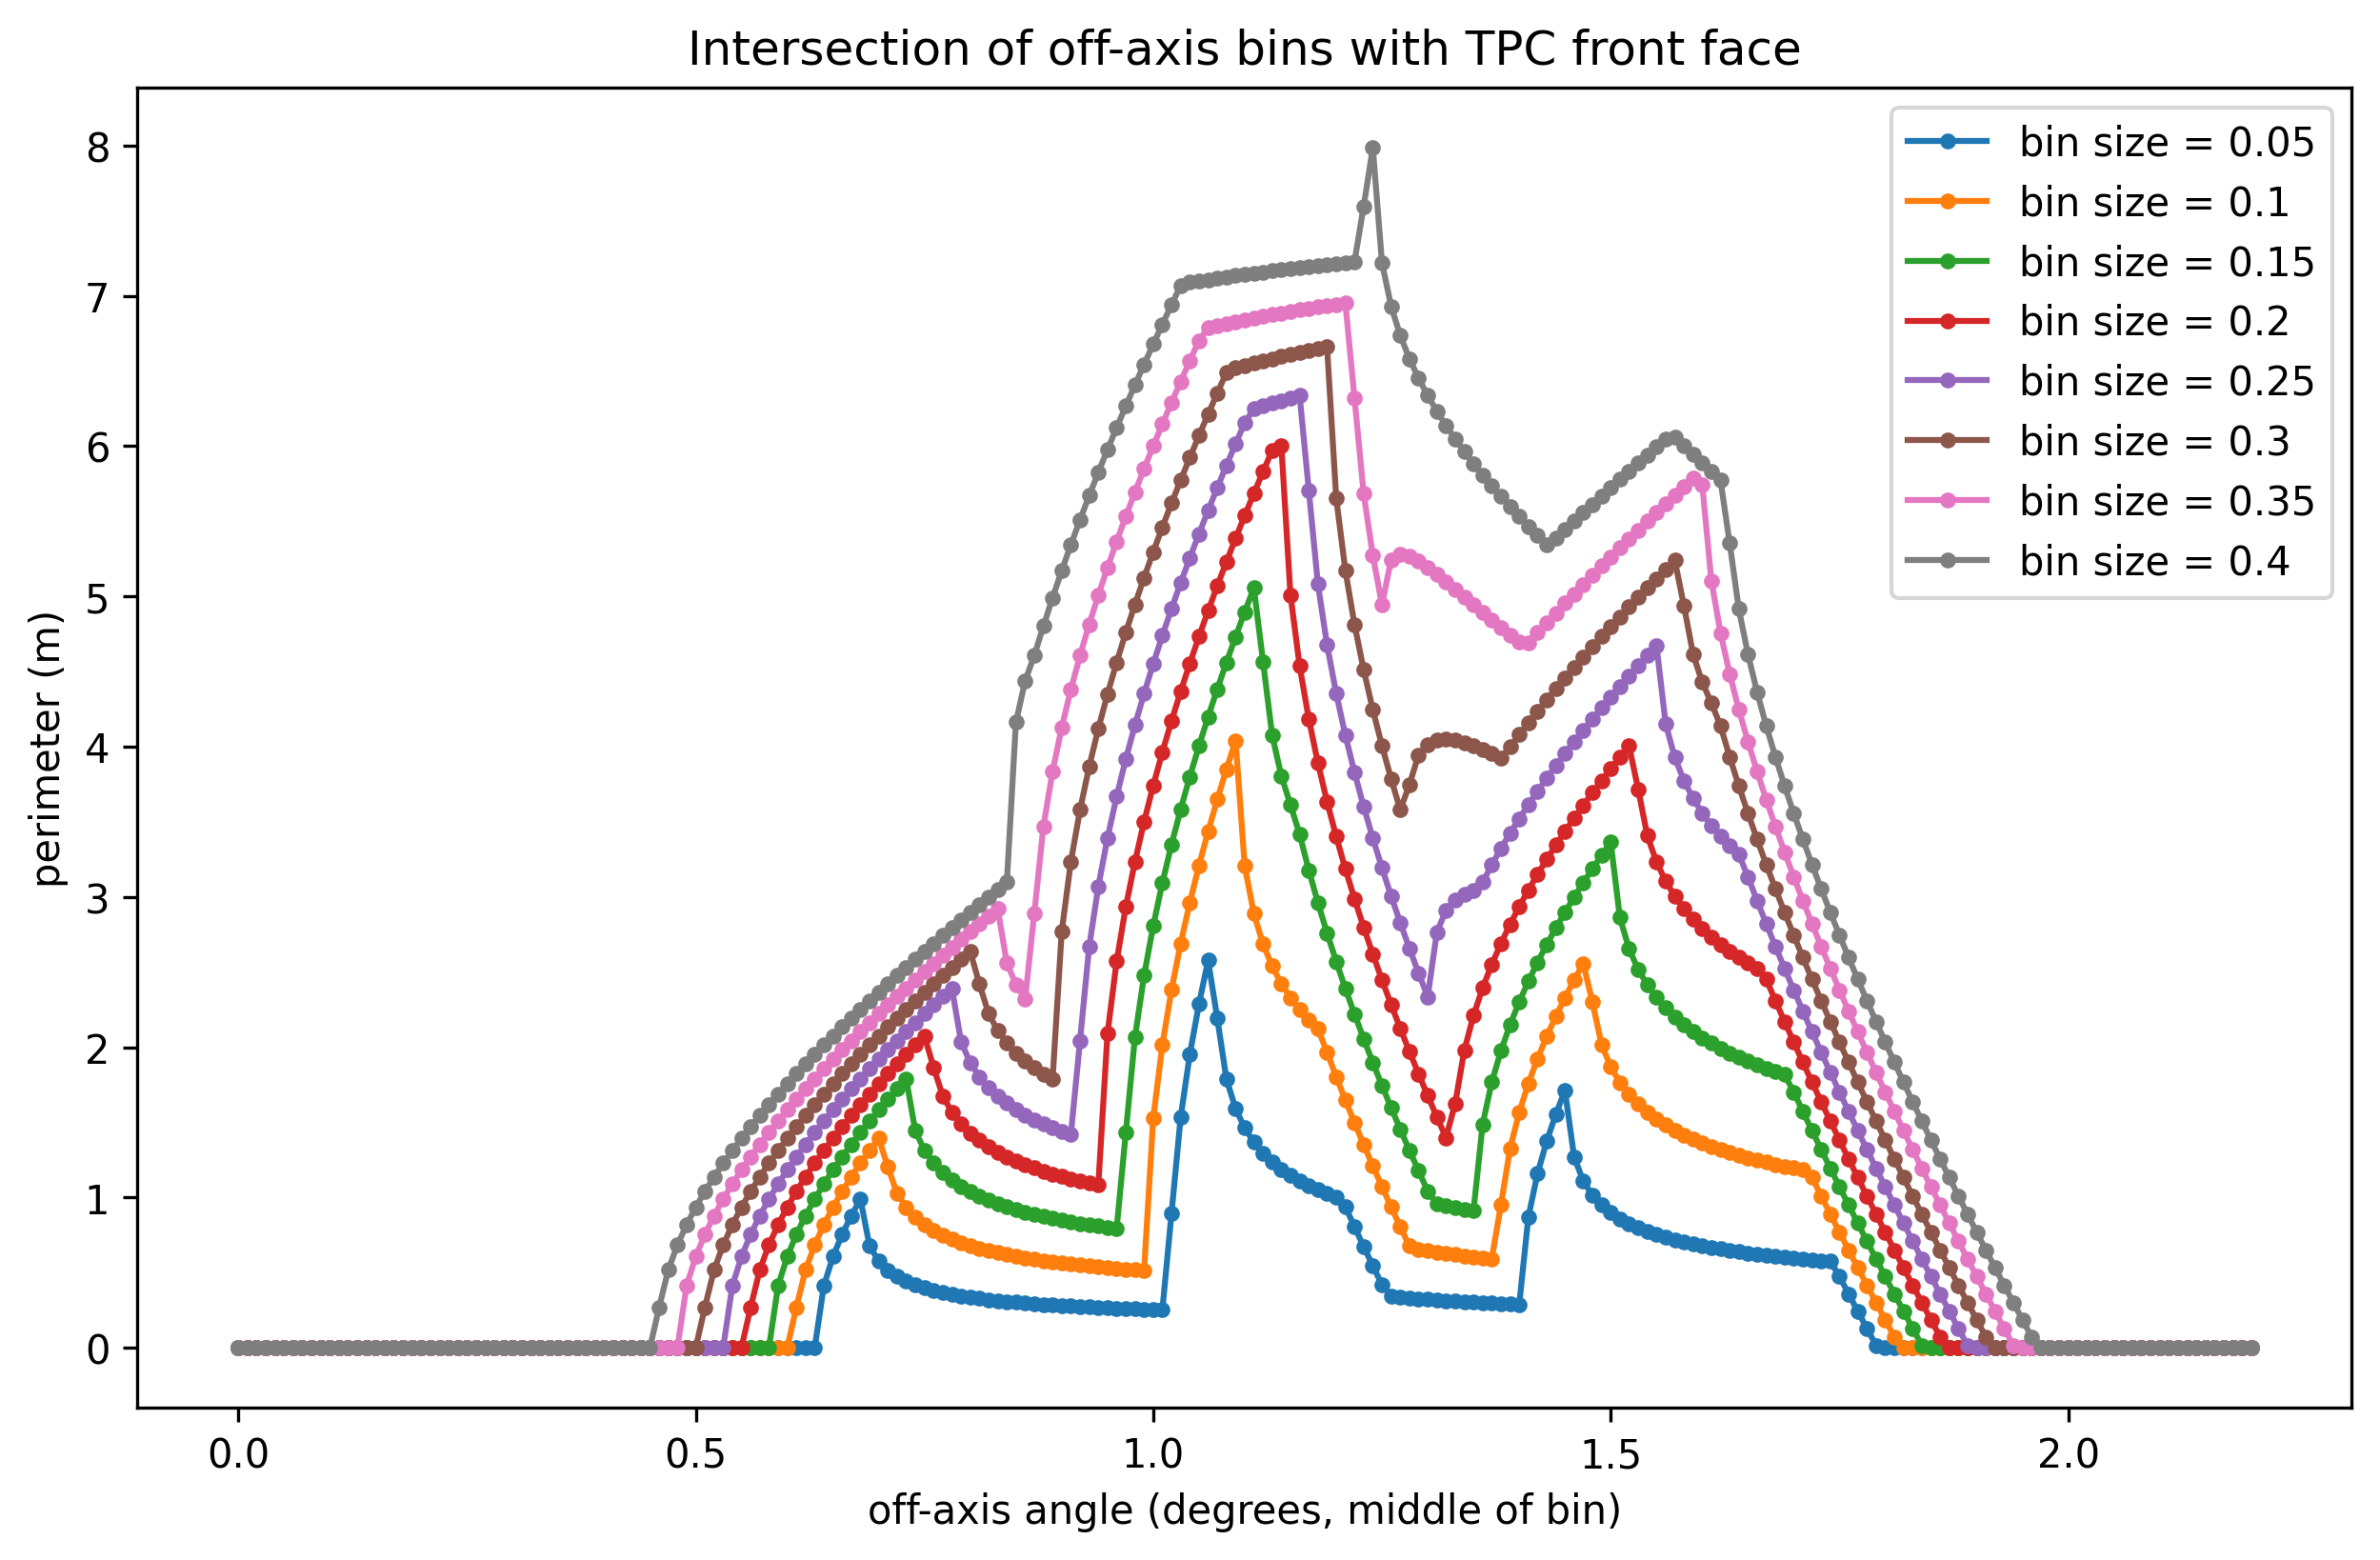

In [75]:
angleSpace = np.arange(0, 2.200001, 0.01)
binnings = np.array([0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4])
plt.figure(figsize=(10, 6), dpi=300)
for b in binnings:
    perms = np.array([])
    for a in angleSpace:
        if a < b:
            perms = np.append(perms, 0)
        else:
            perms = np.append(perms, getPerimeterFront(a+b/2, a-b/2))
    plt.plot(angleSpace, perms, label=f'bin size = {b}', marker='.')
plt.legend()
plt.xlabel('off-axis angle (degrees, middle of bin)')
plt.ylabel('perimeter (m)')
plt.title('Intersection of off-axis bins with TPC front face')
plt.show()

In [76]:
df = pd.read_pickle('./data.pkl')

2571


<Figure size 3000x1800 with 0 Axes>

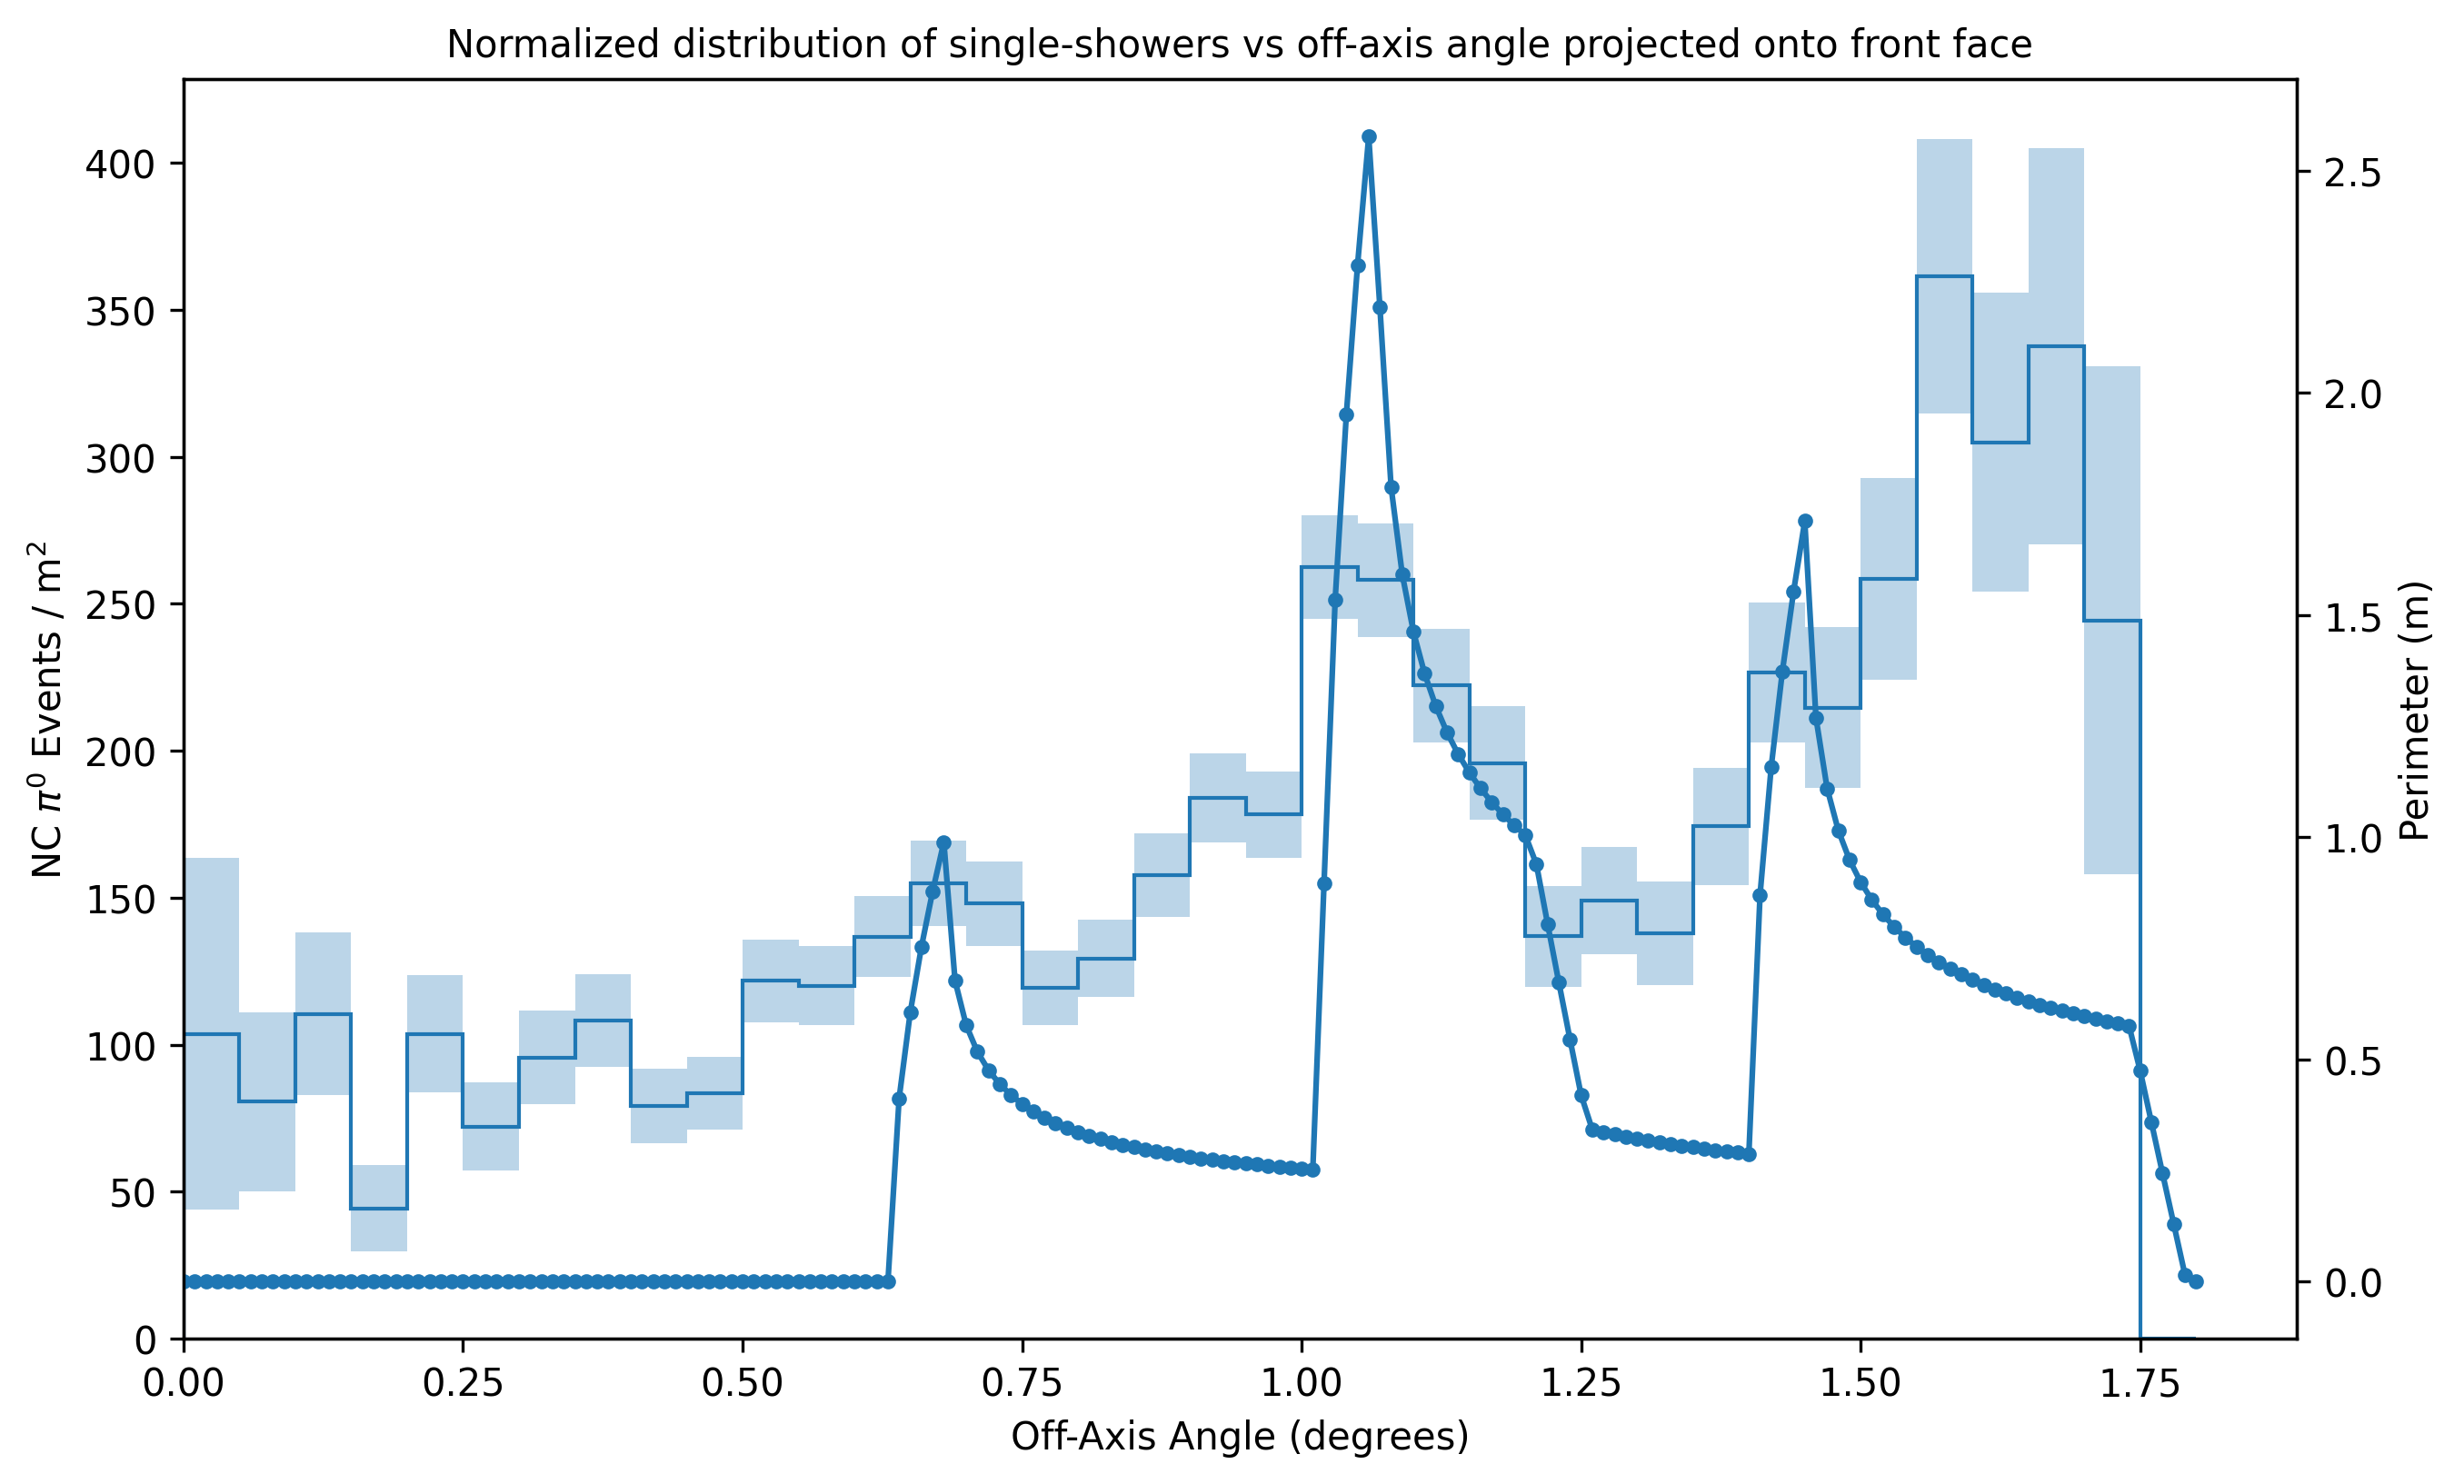

: 

In [ ]:
angles_norm = np.array([])
for idx, row in df[df['is_NC'] & df['single_shower']].iterrows():
    angles_norm = np.append(angles_norm, row['shower_angle_front'])
print(len(angles_norm))

angleSpace = np.arange(0, 1.8001, 0.01)
b = nbinsTPC[1]
color = 'C' + str(int(b/0.05 - 1))

fig, ax1 = plt.subplots(figsize=(10,6), dpi=300)
counts, bins, _ = ax1.hist(angles_norm, bins=nbinsTPC, histtype='step')
wide = np.diff(bins)
norm_counts = counts / norm_areas
plt.clf()  # clear the previous plot
fig, ax1 = plt.subplots(figsize=(10,6), dpi=300)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
errors = np.sqrt(counts) / norm_areas
ax1.bar(bin_centers, 2*errors, width=wide, bottom=norm_counts-errors, color=color, alpha=erAlpha, align='center', edgecolor='none')
ax1.hist(bins[:-1], bins=bins, weights=norm_counts, histtype='step', color=color)

ax1.set_title('Normalized distribution of single-showers vs off-axis angle projected onto front face', fontsize = 10)
ax1.set_xlabel('Off-Axis Angle (degrees)')
ax1.set_ylabel(r'NC $\pi^0$ Events / m$^2$')
ax1.set_xlim(*xlimit)
ax1.set_ylim(*ylimit)
ax1.tick_params(axis='y')

perms = np.array([])
for a in angleSpace:
    if a < b:
        perms = np.append(perms, 0)
    else:
        perms = np.append(perms, getPerimeterFront(a+b/2, a-b/2))
ax2 = ax1.twinx()
ax2.plot(angleSpace, perms, label=f'bin size = {b}', marker='.', color=color)
ax2.set_ylabel('Perimeter (m)')
ax2.tick_params(axis='y')
#fig.tight_layout()
plt.show()

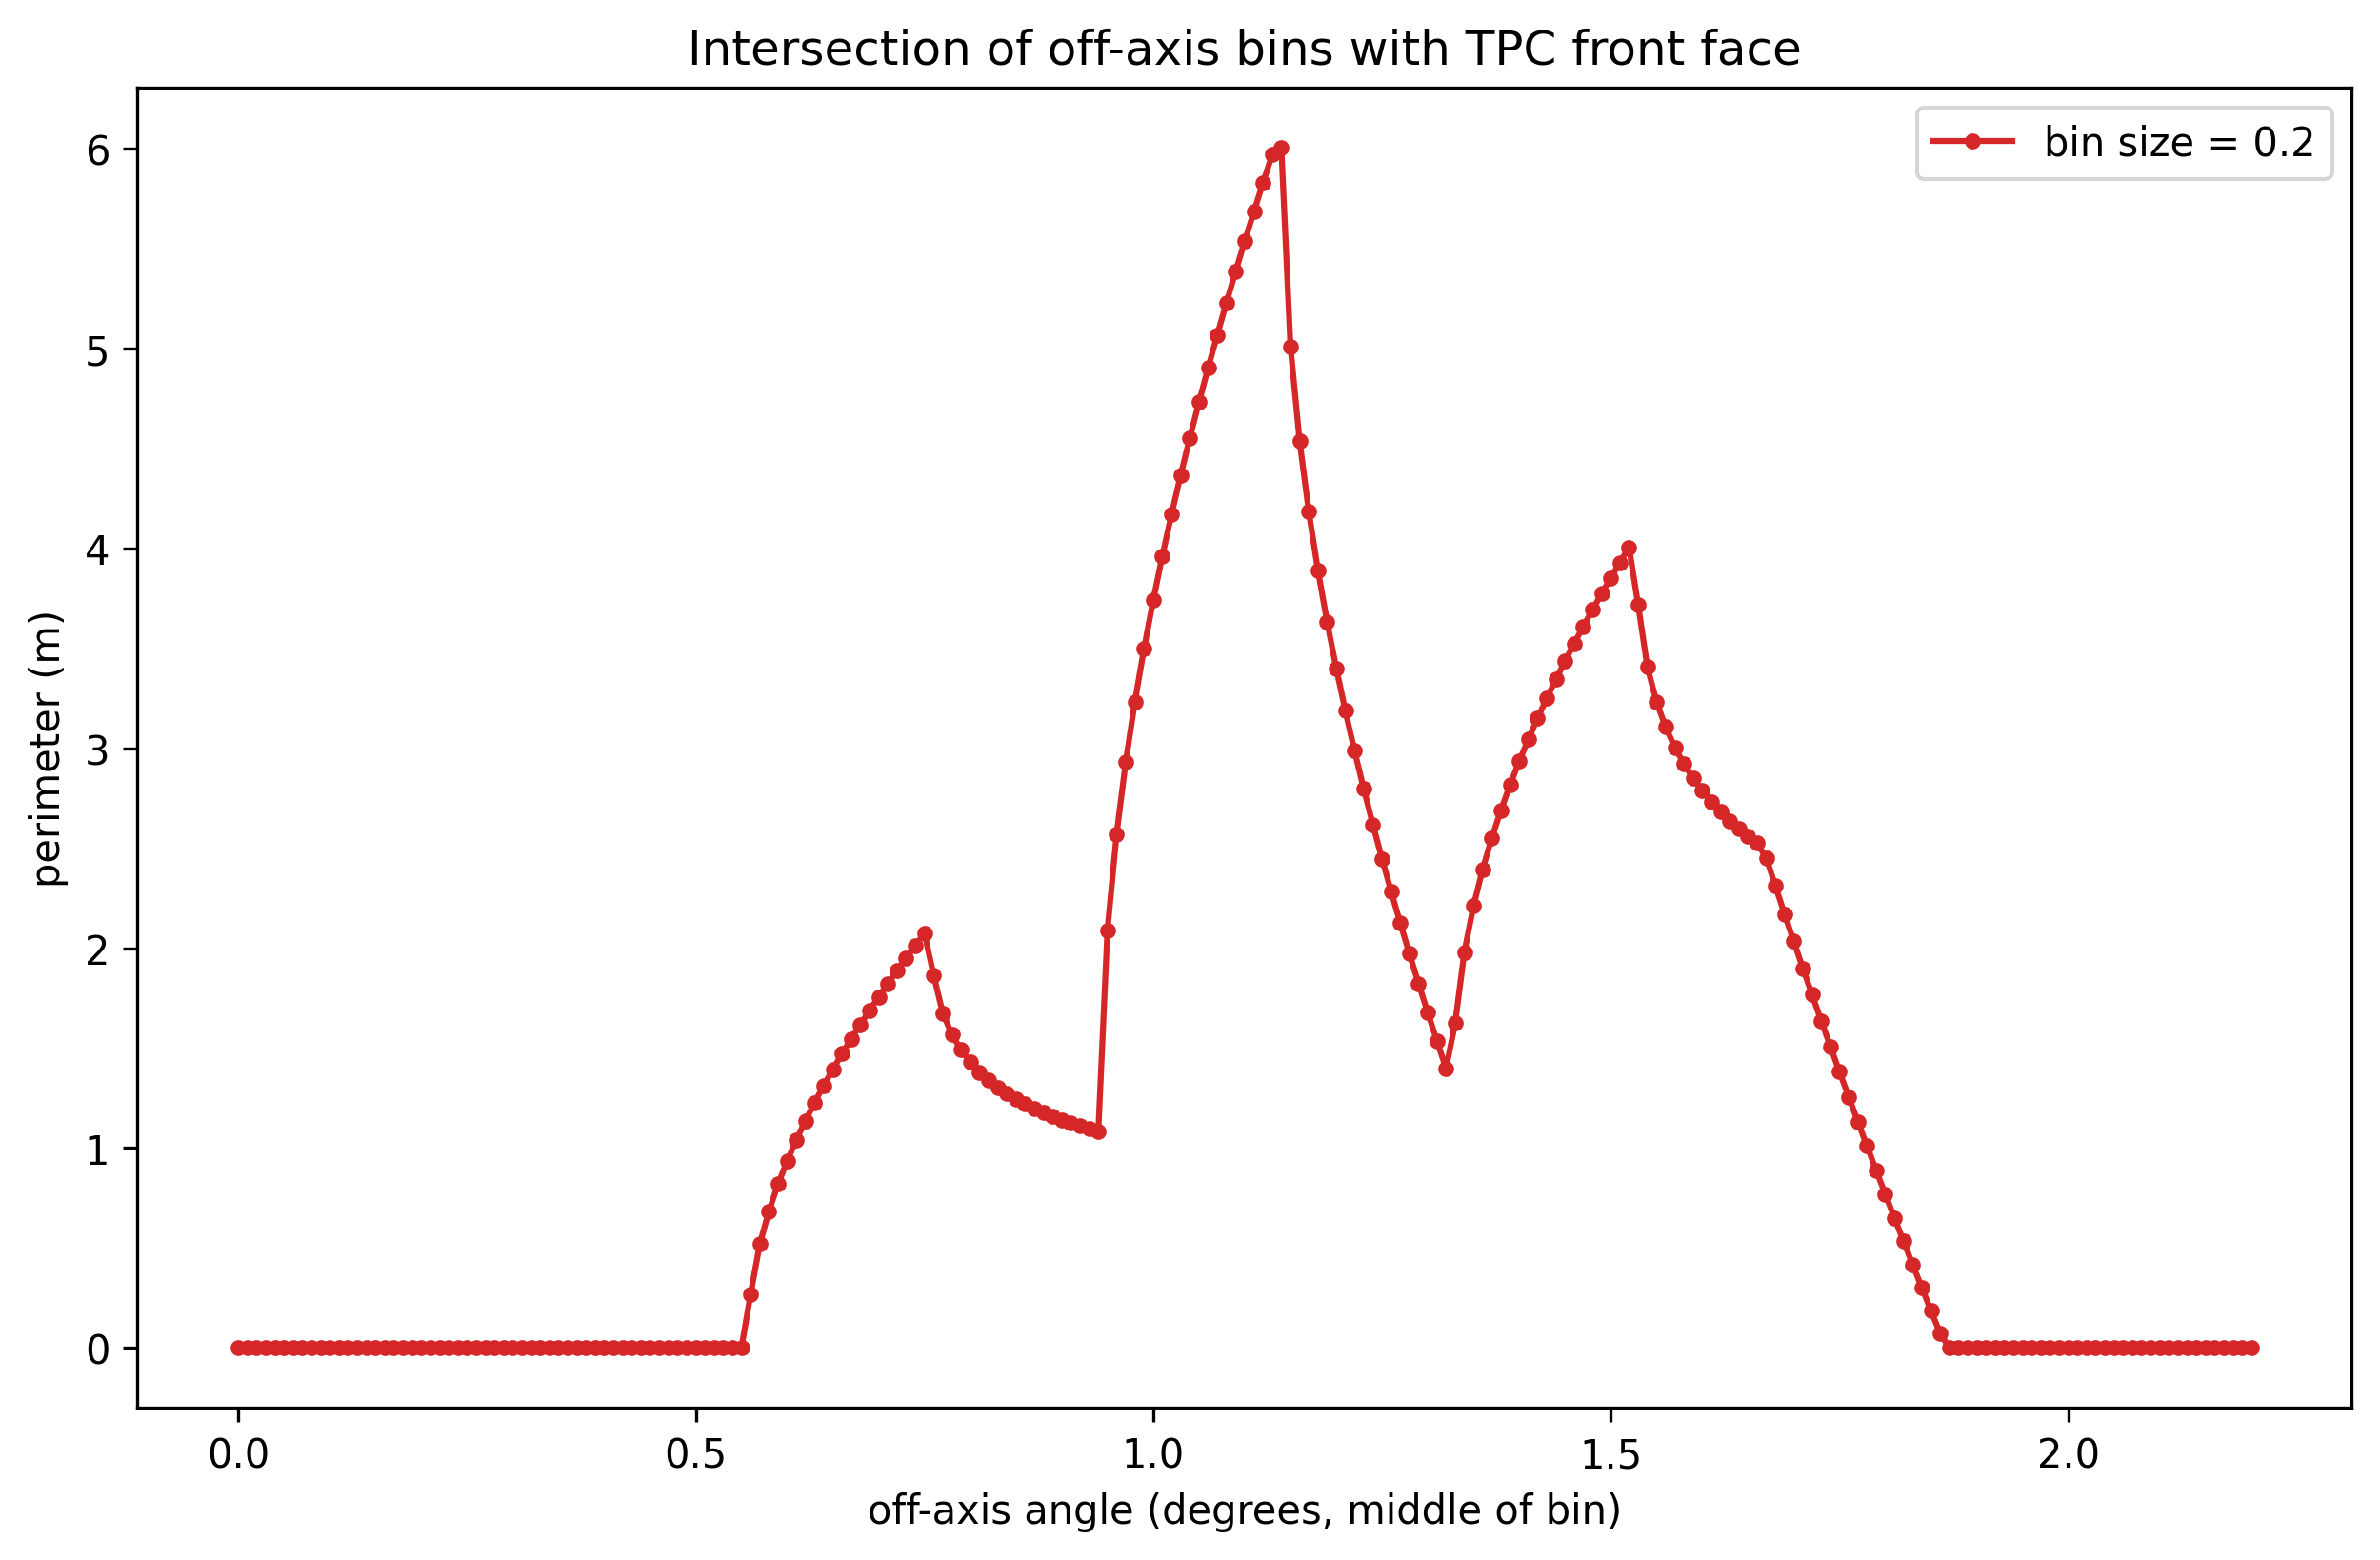

In [78]:
angleSpace = np.arange(0, 2.200001, 0.01)
binnings = np.array([0.2])
plt.figure(figsize=(10, 6), dpi=300)
for b in binnings:
    perms = np.array([])
    for a in angleSpace:
        if a < b:
            perms = np.append(perms, 0)
        else:
            perms = np.append(perms, getPerimeterFront(a+b/2, a-b/2))
    plt.plot(angleSpace, perms, label=f'bin size = {b}', marker='.', color='C3')
plt.legend()
plt.xlabel('off-axis angle (degrees, middle of bin)')
plt.ylabel('perimeter (m)')
plt.title('Intersection of off-axis bins with TPC front face')
plt.show()